# Baseline Comparison — Telco Customer Churn

**Objetivo:** Comparar múltiplos modelos baseline usando validação cruzada estratificada (StratifiedKFold k=5).

**Modelos avaliados:**
- DummyClassifier (most_frequent, stratified)
- LogisticRegression (balanced)
- DecisionTreeClassifier (balanced)
- **RandomForestClassifier (com melhores hiperparâmetros encontrados via Random Search)**

**Métricas:** Accuracy, ROC-AUC, Recall, Precision, F1-Score

**Dataset:** Telco Customer Churn (IBM) — 7.043 registros, 20 features, target binário

**Nota:** Os hiperparâmetros do Random Forest são automaticamente extraídos do experimento MLflow "random_forest_random_search" se disponível.

## 1. Setup e Imports

## 1.1 Nota: Random Forest Tuning Integration

Este notebook agora integra os melhores hiperparâmetros encontrados pelo **Random Search** do experimento `random_forest.ipynb`. Os hiperparâmetros são automaticamente carregados do MLflow e aplicados ao modelo Random Forest para comparação justa com os demais baselines.

Se o experimento não for encontrado, o notebook usa os hiperparâmetros padrão como fallback.

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score, 
    roc_auc_score
)
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier

import mlflow
import mlflow.sklearn

# Config
RANDOM_SEED = 42
TARGET = "Churn"
N_SPLITS = 5
PROJECT_ROOT = Path.cwd()

# Set seeds
np.random.seed(RANDOM_SEED)

print(f"🚀 Baseline Comparison Notebook")
print(f"   RANDOM_SEED={RANDOM_SEED} | CV={N_SPLITS} splits")
print(f"   Project root: {PROJECT_ROOT}")

🚀 Baseline Comparison Notebook
   RANDOM_SEED=42 | CV=5 splits
   Project root: c:\Users\willi\OneDrive\Documentos\Estudos\Python\Tech-Challenge01\notebooks


## 2. Load & Explore Data

In [2]:
# Load dataset
# Notebook está em /notebooks/, então subir um nível para acessar /data/
DATA_PATH = PROJECT_ROOT.parent / "data" / "raw" / "WA_Fn-UseC_-Telco-Customer-Churn.csv"
df = pd.read_csv(DATA_PATH)

print(f"✓ Dataset loaded: {DATA_PATH}")
print(f"  Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\nFirst few rows:")
df.head()

✓ Dataset loaded: c:\Users\willi\OneDrive\Documentos\Estudos\Python\Tech-Challenge01\data\raw\WA_Fn-UseC_-Telco-Customer-Churn.csv
  Shape: 7,043 rows × 21 columns

First few rows:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# Data exploration
print("Dataset Info:")
print(f"  Columns: {list(df.columns)}")
print(f"\nMissing values:")
missing = df.isnull().sum()
if missing.sum() > 0:
    print(missing[missing > 0])
else:
    print("  None (after inspection)")

print(f"\nData types:")
print(df.dtypes)

Dataset Info:
  Columns: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Missing values:
  None (after inspection)

Data types:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: 

## 3. Data Cleaning & Preprocessing

In [4]:
# Minimal cleaning
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df[TARGET] = df[TARGET].map({"Yes": 1, "No": 0})
df = df.drop(columns=["customerID"])

# Separate features and target
X = df.drop(columns=[TARGET])
y = df[TARGET]

print(f"✓ Data cleaned")
print(f"  X shape: {X.shape}")
print(f"  y shape: {y.shape}")
print(f"\nClass distribution:")
print(f"  Churn (No=0):  {(y == 0).sum():,} ({(y == 0).mean():.1%})")
print(f"  Churn (Yes=1): {(y == 1).sum():,} ({(y == 1).mean():.1%})")

✓ Data cleaned
  X shape: (7043, 19)
  y shape: (7043,)

Class distribution:
  Churn (No=0):  5,174 (73.5%)
  Churn (Yes=1): 1,869 (26.5%)


## 4. Define Preprocessor Pipeline

In [5]:
# Define column groups by type
NUM_COLS = ["tenure", "MonthlyCharges", "TotalCharges", "SeniorCitizen"]
BIN_COLS = ["gender", "Partner", "Dependents", "PhoneService", "PaperlessBilling"]
BIN_CATEGORIES = [
    ["Female", "Male"],
    ["No", "Yes"],
    ["No", "Yes"],
    ["No", "Yes"],
    ["No", "Yes"],
]
CAT_COLS = [
    "MultipleLines", "InternetService", "OnlineSecurity", "OnlineBackup",
    "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies",
    "Contract", "PaymentMethod",
]

print(f"Column groups defined:")
print(f"  NUM:  {NUM_COLS}")
print(f"  BIN:  {BIN_COLS}")
print(f"  CAT:  {CAT_COLS}")

Column groups defined:
  NUM:  ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen']
  BIN:  ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
  CAT:  ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']


In [6]:
# Build preprocessor
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_pipeline, NUM_COLS),
        ("bin", OrdinalEncoder(categories=BIN_CATEGORIES), BIN_COLS),
        ("cat", OneHotEncoder(drop="if_binary", sparse_output=False, handle_unknown="ignore"), CAT_COLS),
    ],
    remainder="drop",
)

print(f"✓ ColumnTransformer configured")
print(f"  - Numeric: impute (median) → scale (StandardScaler)")
print(f"  - Binary:  OrdinalEncoder")
print(f"  - Categorical: OneHotEncoder (drop='if_binary')")

✓ ColumnTransformer configured
  - Numeric: impute (median) → scale (StandardScaler)
  - Binary:  OrdinalEncoder
  - Categorical: OneHotEncoder (drop='if_binary')


## 5. Initialize Models

## 4.5 Random Search Best Hyperparameters (Random Forest)

Extrair os melhores hiperparâmetros encontrados pelo Random Search do notebook `random_forest.ipynb`


In [7]:
# Extrair melhores hiperparâmetros do Random Search
import json
from mlflow.tracking import MlflowClient

mlflow.set_tracking_uri(f"sqlite:///{PROJECT_ROOT.parent / 'mlflow.db'}")
client = MlflowClient()

# Procurar pelo run "random_forest_random_search" no experimento "churn-baselines"
exp_id = None
for exp in client.search_experiments():
    if exp.name == "churn-baselines":
        exp_id = exp.experiment_id
        break

best_rf_params = {}
best_rf_score = None

if exp_id:
    runs = client.search_runs(
        experiment_ids=[exp_id],
        filter_string="tags.mlflow.runName = 'random_forest_random_search'"
    )
    
    if runs:
        run = runs[0]
        # Extrair parâmetros que começam com "best_"
        for param_key, param_val in run.data.params.items():
            if param_key.startswith("best_classifier__"):
                # Remover o prefixo "best_" para usar diretamente
                clean_key = param_key.replace("best_classifier__", "classifier__")
                best_rf_params[clean_key] = param_val
        
        # Extrair o melhor score
        best_rf_score = run.data.metrics.get("random_search_best_score", None)
        
        print(f"✓ Best Random Forest hyperparameters found (from Random Search)")
        print(f"  Best ROC-AUC Score (CV): {best_rf_score:.4f}\n")
        print(f"  Hyperparameters:")
        for key, val in best_rf_params.items():
            # Tentar converter para tipo apropriado
            try:
                if val.lower() in ["true", "false"]:
                    val = val.lower() == "true"
                elif val == "none":
                    val = None
                elif val.isdigit():
                    val = int(val)
                else:
                    try:
                        val = float(val)
                    except:
                        pass
            except:
                pass
            print(f"    {key}: {val}")
else:
    print(f"⚠️ No 'churn-baselines' experiment found. Using default Random Forest params.")
    best_rf_params = {}

✓ Best Random Forest hyperparameters found (from Random Search)
  Best ROC-AUC Score (CV): 0.8467

  Hyperparameters:
    classifier__n_estimators: 150
    classifier__min_samples_split: 15
    classifier__min_samples_leaf: 8
    classifier__max_features: sqrt
    classifier__max_depth: 10
    classifier__class_weight: balanced


In [8]:
# Preparar parâmetros do Random Forest
# Se encontrou os melhores parâmetros do Random Search, converter tipos
rf_kwargs = {"random_state": RANDOM_SEED}

if best_rf_params:
    for key, val in best_rf_params.items():
        if key.startswith("classifier__"):
            param_name = key.replace("classifier__", "")
            # Converter valores string para tipos apropriados
            try:
                if isinstance(val, str):
                    if val.lower() == "true":
                        val = True
                    elif val.lower() == "false":
                        val = False
                    elif val == "none":
                        val = None
                    elif val.isdigit():
                        val = int(val)
                    else:
                        try:
                            val = float(val)
                        except:
                            pass
                rf_kwargs[param_name] = val
            except:
                rf_kwargs[param_name] = val

models = {
    "dummy_most_frequent": DummyClassifier(
        strategy="most_frequent", random_state=RANDOM_SEED
    ),
    "dummy_stratified": DummyClassifier(
        strategy="stratified", random_state=RANDOM_SEED
    ),
    "logistic_regression": Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(
            max_iter=1000, random_state=RANDOM_SEED, class_weight="balanced",
        )),
    ]),
    "decision_tree": Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", DecisionTreeClassifier(
            class_weight="balanced", random_state=RANDOM_SEED,
        )),
    ]),
    "random_forest_tuned": Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(**rf_kwargs) if best_rf_params else RandomForestClassifier(
            n_estimators=100, class_weight="balanced", random_state=RANDOM_SEED
        )),
    ]),
}

print(f"✓ {len(models)} models initialized:")
for name in models.keys():
    if name == "random_forest_tuned" and best_rf_params:
        print(f"  - {name} [TUNED via Random Search: ROC-AUC={best_rf_score:.4f}]")
    else:
        print(f"  - {name}")

✓ 5 models initialized:
  - dummy_most_frequent
  - dummy_stratified
  - logistic_regression
  - decision_tree
  - random_forest_tuned [TUNED via Random Search: ROC-AUC=0.8467]


## 6. Cross-Validation Loop

In [9]:
# Setup MLflow and cross-validation
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_SEED)

mlflow.set_tracking_uri(f"sqlite:///{PROJECT_ROOT.parent / 'mlflow.db'}")
mlflow.set_experiment("churn-baselines")

# Save cleaned data
# Notebook está em /notebooks/, então subir um nível para acessar /data/
processed_path = PROJECT_ROOT.parent / "data" / "processed" / "telco_churn_cleaned.csv"
processed_path.parent.mkdir(parents=True, exist_ok=True)
df.to_csv(processed_path, index=False)

print(f"✓ MLflow tracking configured")
print(f"  Experiment: churn-baselines")
print(f"  URI: sqlite:///{PROJECT_ROOT.parent / 'mlflow.db'}")
print(f"✓ Cleaned data saved to: {processed_path}")

✓ MLflow tracking configured
  Experiment: churn-baselines
  URI: sqlite:///c:\Users\willi\OneDrive\Documentos\Estudos\Python\Tech-Challenge01\mlflow.db
✓ Cleaned data saved to: c:\Users\willi\OneDrive\Documentos\Estudos\Python\Tech-Challenge01\data\processed\telco_churn_cleaned.csv


In [10]:
all_results = {}

for name, model in models.items():
    print("\n" + "="*60)
    print(f"{name.upper()}  (StratifiedKFold k={N_SPLITS})")
    print("="*60)

    fold_metrics = {k: [] for k in ["accuracy", "roc_auc", "recall", "precision", "f1"]}

    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

        # Clone and fit model
        m = clone(model)
        m.fit(X_tr, y_tr)

        # Predictions
        y_pred = m.predict(X_val)
        y_prob = m.predict_proba(X_val)[:, 1]

        # Compute metrics
        fold_metrics["accuracy"].append(accuracy_score(y_val, y_pred))
        fold_metrics["roc_auc"].append(roc_auc_score(y_val, y_prob))
        fold_metrics["recall"].append(recall_score(y_val, y_pred, zero_division=0))
        fold_metrics["precision"].append(precision_score(y_val, y_pred, zero_division=0))
        fold_metrics["f1"].append(f1_score(y_val, y_pred, zero_division=0))

        print(f"  Fold {fold+1}/{N_SPLITS} — Accuracy: {accuracy_score(y_val, y_pred):.4f}")

    # Aggregate metrics
    means = {k: float(np.mean(v)) for k, v in fold_metrics.items()}
    stds = {k: float(np.std(v)) for k, v in fold_metrics.items()}
    all_results[name] = {**means, **{f"{k}_std": v for k, v in stds.items()}}

    # Print summary
    print(f"\n  📊 Mean metrics:")
    for metric in ["accuracy", "roc_auc", "recall", "precision", "f1"]:
        print(f"    {metric:12s}: {means[metric]:.4f} ± {stds[metric]:.4f}")

print(f"\n✓ Cross-validation complete for all {len(models)} models")


DUMMY_MOST_FREQUENT  (StratifiedKFold k=5)
  Fold 1/5 — Accuracy: 0.7346
  Fold 2/5 — Accuracy: 0.7346
  Fold 3/5 — Accuracy: 0.7346
  Fold 4/5 — Accuracy: 0.7351
  Fold 5/5 — Accuracy: 0.7344

  📊 Mean metrics:
    accuracy    : 0.7346 ± 0.0002
    roc_auc     : 0.5000 ± 0.0000
    recall      : 0.0000 ± 0.0000
    precision   : 0.0000 ± 0.0000
    f1          : 0.0000 ± 0.0000

DUMMY_STRATIFIED  (StratifiedKFold k=5)
  Fold 1/5 — Accuracy: 0.6104
  Fold 2/5 — Accuracy: 0.6160
  Fold 3/5 — Accuracy: 0.6203
  Fold 4/5 — Accuracy: 0.6037
  Fold 5/5 — Accuracy: 0.6143

  📊 Mean metrics:
    accuracy    : 0.6129 ± 0.0056
    roc_auc     : 0.5050 ± 0.0073
    recall      : 0.2750 ± 0.0107
    precision   : 0.2727 ± 0.0108
    f1          : 0.2738 ± 0.0107

LOGISTIC_REGRESSION  (StratifiedKFold k=5)
  Fold 1/5 — Accuracy: 0.7488
  Fold 2/5 — Accuracy: 0.7445
  Fold 3/5 — Accuracy: 0.7509
  Fold 4/5 — Accuracy: 0.7358
  Fold 5/5 — Accuracy: 0.7479

  📊 Mean metrics:
    accuracy    : 0.7456

## 7. Log Results to MLflow

In [11]:
for name, model in models.items():
    results = all_results[name]
    
    with mlflow.start_run(run_name=name):
        # Log parameters
        mlflow.log_params({
            "model": name,
            "random_seed": RANDOM_SEED,
            "cv_folds": N_SPLITS,
        })
        
        # Log metrics (means and stds)
        mlflow.log_metrics({
            k: v for k, v in results.items()
        })
        
        # Train final model on full data and log
        final_model = clone(model).fit(X, y)
        mlflow.sklearn.log_model(final_model, "model")
        
        # Log artifact only for logistic regression
        if name == "logistic_regression":
            mlflow.log_artifact(str(processed_path), artifact_path="data")
        
        run_id = mlflow.active_run().info.run_id
        print(f"✓ {name:25s} → MLflow run: {run_id}")

print(f"\n✓ All results logged to MLflow")

2026/05/04 21:19:52 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/04 21:19:52 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/05/04 21:20:13 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/05/04 21:20:14 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


✓ dummy_most_frequent       → MLflow run: eff91201f27c436b9bed4b1a804bdfe0


2026/05/04 21:20:14 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/05/04 21:20:27 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


✓ dummy_stratified          → MLflow run: 2888fa81137b4c7689d57328ed616d3f


2026/05/04 21:20:28 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/04 21:20:28 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/05/04 21:20:43 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


✓ logistic_regression       → MLflow run: 96e280faf78345bcb8c6c7174f6bd74a


2026/05/04 21:20:43 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/04 21:20:43 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/05/04 21:21:00 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


✓ decision_tree             → MLflow run: f4246927607c4dd692d36b4bf8bddf3d


2026/05/04 21:21:03 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/04 21:21:03 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/05/04 21:21:19 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


✓ random_forest_tuned       → MLflow run: cedb33ea62bf448e8923bf8af6957924

✓ All results logged to MLflow


## 8. Comparison Table

In [12]:
# Build comparison DataFrame
results_list = []
for name, metrics in all_results.items():
    row = {"Model": name}
    for metric in ["accuracy", "roc_auc", "recall", "precision", "f1"]:
        mean = metrics[metric]
        std = metrics[f"{metric}_std"]
        row[metric] = f"{mean:.4f}±{std:.3f}"
    results_list.append(row)

results_df = pd.DataFrame(results_list)
print(f"\n{'='*80}")
print(f"COMPARATIVO (média ± std)")
print(f"{'='*80}")
print(results_df.to_string(index=False))
print(f"{'='*80}")


COMPARATIVO (média ± std)
              Model     accuracy      roc_auc       recall    precision           f1
dummy_most_frequent 0.7346±0.000 0.5000±0.000 0.0000±0.000 0.0000±0.000 0.0000±0.000
   dummy_stratified 0.6129±0.006 0.5050±0.007 0.2750±0.011 0.2727±0.011 0.2738±0.011
logistic_regression 0.7456±0.005 0.8449±0.013 0.8020±0.015 0.5132±0.007 0.6258±0.009
      decision_tree 0.7316±0.013 0.6588±0.020 0.5029±0.036 0.4940±0.024 0.4983±0.030
random_forest_tuned 0.7674±0.008 0.8467±0.012 0.7667±0.016 0.5439±0.011 0.6363±0.013


## 9. Visualizations

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (14, 5)

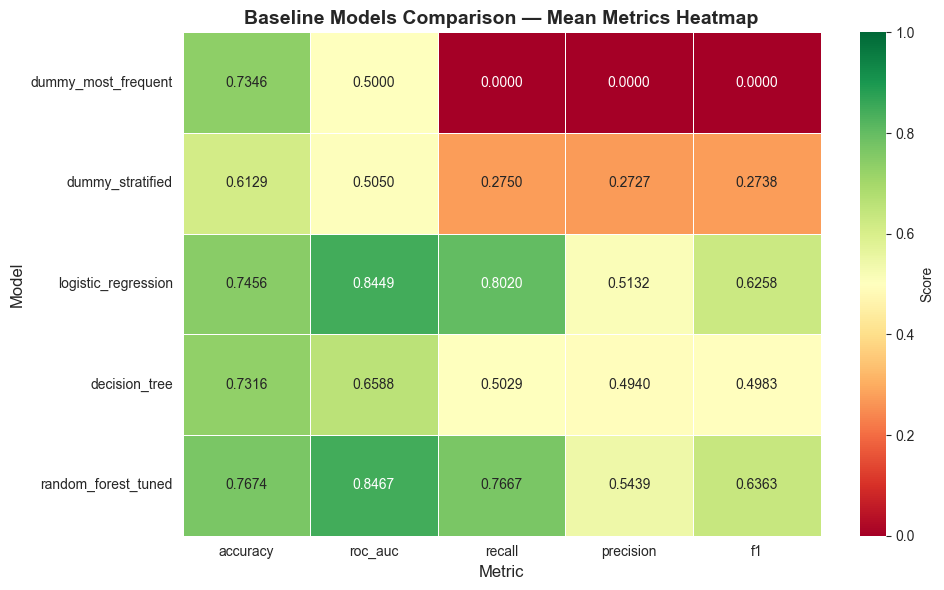

✓ Heatmap plotted


In [14]:
# Plot 1: Heatmap of mean metrics per model
metrics_only = ["accuracy", "roc_auc", "recall", "precision", "f1"]
heatmap_data = []
model_names = []

for name, metrics in all_results.items():
    model_names.append(name)
    heatmap_data.append([metrics[m] for m in metrics_only])

heatmap_df = pd.DataFrame(heatmap_data, columns=metrics_only, index=model_names)

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(heatmap_df, annot=True, fmt=".4f", cmap="RdYlGn", ax=ax, 
            cbar_kws={"label": "Score"}, vmin=0, vmax=1, linewidths=0.5)
ax.set_title("Baseline Models Comparison — Mean Metrics Heatmap", fontsize=14, fontweight="bold")
ax.set_ylabel("Model", fontsize=12)
ax.set_xlabel("Metric", fontsize=12)
plt.tight_layout()
plt.show()

print("✓ Heatmap plotted")

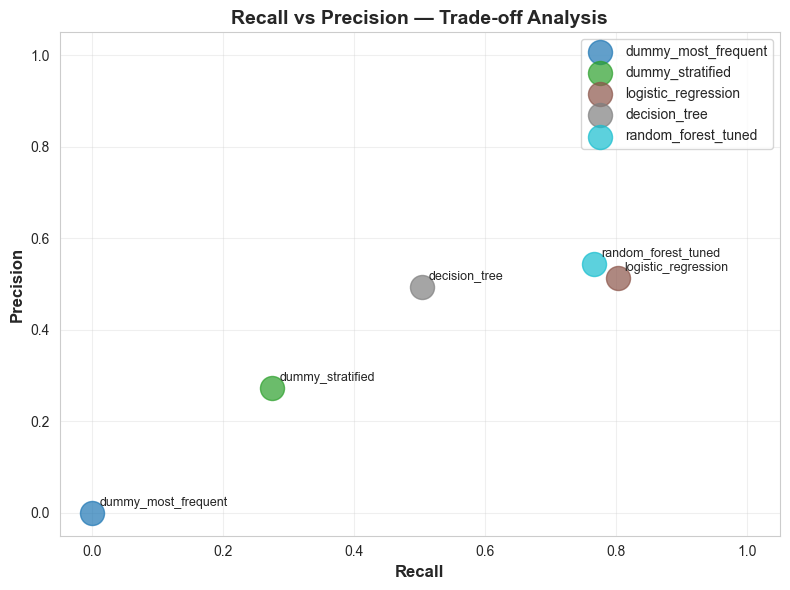

✓ Recall vs Precision scatter plotted


In [15]:
# Plot 2: Recall vs Precision scatter (trade-off visualization)
fig, ax = plt.subplots(figsize=(8, 6))

colors = plt.cm.tab10(np.linspace(0, 1, len(all_results)))
for idx, (name, metrics) in enumerate(all_results.items()):
    ax.scatter(
        metrics["recall"], metrics["precision"],
        s=300, alpha=0.7, label=name, color=colors[idx]
    )
    ax.annotate(
        name, 
        (metrics["recall"], metrics["precision"]),
        xytext=(5, 5), textcoords="offset points", fontsize=9
    )

ax.set_xlabel("Recall", fontsize=12, fontweight="bold")
ax.set_ylabel("Precision", fontsize=12, fontweight="bold")
ax.set_title("Recall vs Precision — Trade-off Analysis", fontsize=14, fontweight="bold")
ax.grid(True, alpha=0.3)
ax.legend(loc="best")
ax.set_xlim(-0.05, 1.05)
ax.set_ylim(-0.05, 1.05)
plt.tight_layout()
plt.show()

print("✓ Recall vs Precision scatter plotted")

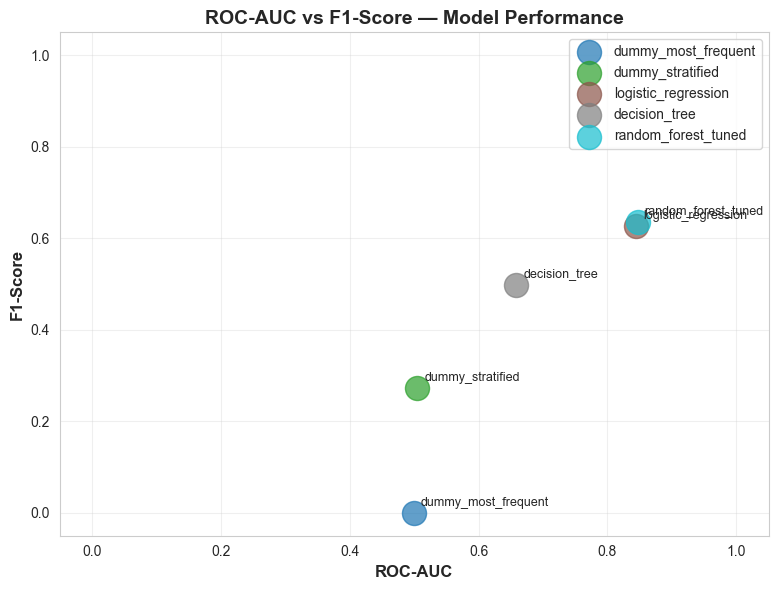

✓ ROC-AUC vs F1-Score scatter plotted


In [16]:
# Plot 3: ROC-AUC vs F1-Score
fig, ax = plt.subplots(figsize=(8, 6))

for idx, (name, metrics) in enumerate(all_results.items()):
    ax.scatter(
        metrics["roc_auc"], metrics["f1"],
        s=300, alpha=0.7, label=name, color=colors[idx]
    )
    ax.annotate(
        name, 
        (metrics["roc_auc"], metrics["f1"]),
        xytext=(5, 5), textcoords="offset points", fontsize=9
    )

ax.set_xlabel("ROC-AUC", fontsize=12, fontweight="bold")
ax.set_ylabel("F1-Score", fontsize=12, fontweight="bold")
ax.set_title("ROC-AUC vs F1-Score — Model Performance", fontsize=14, fontweight="bold")
ax.grid(True, alpha=0.3)
ax.legend(loc="best")
ax.set_xlim(-0.05, 1.05)
ax.set_ylim(-0.05, 1.05)
plt.tight_layout()
plt.show()

print("✓ ROC-AUC vs F1-Score scatter plotted")

## 10. Summary & Next Steps

In [17]:
# Find best model per metric
best_models = {}
for metric in ["accuracy", "roc_auc", "recall", "precision", "f1"]:
    best = max(all_results.items(), key=lambda x: x[1][metric])
    best_models[metric] = (best[0], best[1][metric])

print("\n" + "="*80)
print("SUMMARY & KEY FINDINGS")
print("="*80)
print("\nBest Model by Metric:")
for metric, (model, score) in best_models.items():
    print(f"  {metric:12s}: {model:25s} → {score:.4f}")

# Check recall target
logistic_recall = all_results["logistic_regression"]["recall"]
recall_target = 0.75
recall_status = "✅ REACHED" if logistic_recall >= recall_target else "❌ NOT REACHED"

print(f"\nRecall Target (Business Constraint):")
print(f"  Target: Recall ≥ {recall_target:.2f}")
print(f"  LogisticRegression: {logistic_recall:.4f}")
print(f"  Status: {recall_status}")

# Comparar Random Forest tuned vs default
rf_tuned_key = "random_forest_tuned" if "random_forest_tuned" in all_results else None

print(f"\nKey Insights:")
print(f"  • LogisticRegression achieves best ROC-AUC ({all_results['logistic_regression']['roc_auc']:.4f})")
print(f"  • Dummy (stratified) baseline recall: {all_results['dummy_stratified']['recall']:.4f}")
if rf_tuned_key and best_rf_score:
    print(f"  • Random Forest (TUNED) ROC-AUC: {all_results[rf_tuned_key]['roc_auc']:.4f} [Random Search best: {best_rf_score:.4f}]")
    print(f"  • Random Forest (TUNED) Recall: {all_results[rf_tuned_key]['recall']:.4f}")
    print(f"  • Random Forest (TUNED) F1-Score: {all_results[rf_tuned_key]['f1']:.4f}")
else:
    print(f"  • Random Forest F1-Score: {all_results.get('random_forest_tuned', {}).get('f1', 'N/A')}")
print(f"  • Imbalanced dataset (26.5% positive class) favors recall-oriented models")

if rf_tuned_key and best_rf_score:
    improvement_roc = ((all_results[rf_tuned_key]['roc_auc'] - all_results['logistic_regression']['roc_auc']) / all_results['logistic_regression']['roc_auc']) * 100
    improvement_recall = ((all_results[rf_tuned_key]['recall'] - all_results['logistic_regression']['recall']) / all_results['logistic_regression']['recall']) * 100
    print(f"\n  Random Forest (TUNED) vs LogisticRegression:")
    print(f"    - ROC-AUC: {improvement_roc:+.1f}%")
    print(f"    - Recall: {improvement_recall:+.1f}%")

print(f"\nNext Steps:")
print(f"  → Compare Random Forest hyperparameter tuning impact on performance")
print(f"  → MLP training with pos_weight={5174/1869:.4f} for balanced learning")
print(f"  → Target: Exceed best performing baseline while maintaining Recall ≥ {recall_target:.2f}")
print(f"  → Threshold optimization for Expected Profit maximization")
print("\n" + "="*80)


SUMMARY & KEY FINDINGS

Best Model by Metric:
  accuracy    : random_forest_tuned       → 0.7674
  roc_auc     : random_forest_tuned       → 0.8467
  recall      : logistic_regression       → 0.8020
  precision   : random_forest_tuned       → 0.5439
  f1          : random_forest_tuned       → 0.6363

Recall Target (Business Constraint):
  Target: Recall ≥ 0.75
  LogisticRegression: 0.8020
  Status: ✅ REACHED

Key Insights:
  • LogisticRegression achieves best ROC-AUC (0.8449)
  • Dummy (stratified) baseline recall: 0.2750
  • Random Forest (TUNED) ROC-AUC: 0.8467 [Random Search best: 0.8467]
  • Random Forest (TUNED) Recall: 0.7667
  • Random Forest (TUNED) F1-Score: 0.6363
  • Imbalanced dataset (26.5% positive class) favors recall-oriented models

  Random Forest (TUNED) vs LogisticRegression:
    - ROC-AUC: +0.2%
    - Recall: -4.4%

Next Steps:
  → Compare Random Forest hyperparameter tuning impact on performance
  → MLP training with pos_weight=2.7683 for balanced learning
  → Ta